In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,f1_score,accuracy_score,confusion_matrix,roc_auc_score

In [2]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\Navie_Biaz\data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [4]:
df=df.drop(columns=['Unnamed: 32'])

In [5]:
df.shape

(569, 32)

In [6]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [7]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Class distribution (Malignant vs Benign)
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [10]:
# Encode the target variable (M, B) into numerical form and explain why encoding is required.
# LabelEncoder

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['diagnosis']=le.fit_transform(df['diagnosis'])#m=1,b=0


In [11]:
# Separate:Feature matrix X,Target vector y

x=df.drop(columns='diagnosis')#feature
y=df['diagnosis']#Target

In [12]:
# Apply feature scaling (standardization) and answer:Why is scaling important for Gaussian Naive Bayes?

from sklearn.preprocessing import StandardScaler


scale=StandardScaler()
x_scale=scale.fit_transform(x)


In [13]:
# train_test_split

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)



In [14]:
# Standardization
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)



In [15]:
# Variance calculation
variance=x.var().sort_values(ascending=False)
variance

id                         1.563015e+16
area_worst                 3.241674e+05
area_mean                  1.238436e+05
area_se                    2.069432e+03
perimeter_worst            1.129131e+03
perimeter_mean             5.904405e+02
texture_worst              3.777648e+01
radius_worst               2.336022e+01
texture_mean               1.849891e+01
radius_mean                1.241892e+01
perimeter_se               4.087896e+00
texture_se                 3.043159e-01
radius_se                  7.690235e-02
concavity_worst            4.352409e-02
compactness_worst          2.475477e-02
concavity_mean             6.355248e-03
concave points_worst       4.320741e-03
symmetry_worst             3.827584e-03
compactness_mean           2.789187e-03
concave points_mean        1.505661e-03
concavity_se               9.111982e-04
symmetry_mean              7.515428e-04
smoothness_worst           5.213198e-04
fractal_dimension_worst    3.262094e-04
compactness_se             3.207029e-04


Exploratory Data Analysis (EDA)

In [16]:
x=df[['radius_mean', 'texture_mean', 'perimeter_mean','area_mean', 
'smoothness_mean', 'compactness_mean', 'concavity_mean',
'concave points_mean', 'symmetry_mean','fractal_dimension_mean']]

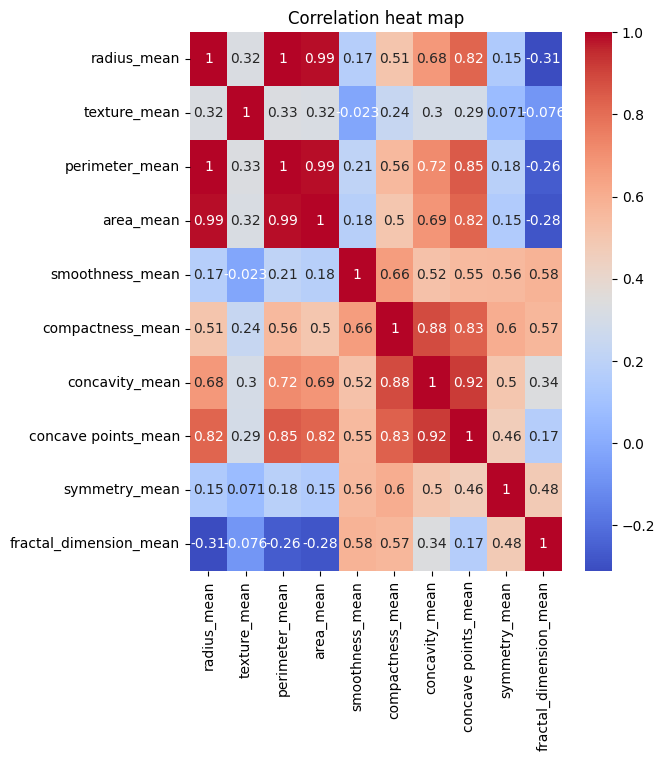

In [17]:
# Plot a correlation heatmap of all numeric features
corr=x.corr()
plt.figure(figsize=(6,7))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation heat map")
plt.show()

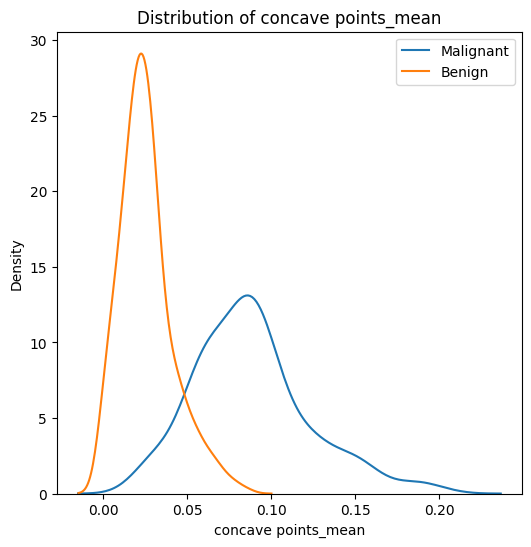

In [18]:
plt.figure(figsize=(6,6))
sns.kdeplot(df[df['diagnosis']==1]['concave points_mean'],label='Malignant')
sns.kdeplot(df[df['diagnosis']==0]['concave points_mean'],label='Benign')
plt.legend()
plt.title("Distribution of concave points_mean")
plt.show()

Part D: Model Understanding (Theory + Terminology) 

Part E: Model Evaluation & Interpretation (Expanded)

In [19]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,auc,confusion_matrix,classification_report

gnb=GaussianNB()
gnb.fit(x_train,y_train)


,priors,None
,var_smoothing,1e-09


In [21]:
y_pred =gnb.predict(x_test)

# Accuracy 
print("Accuracy",accuracy_score(y_test,y_pred))
# confusion matrix
print("Confusion Matrix",confusion_matrix(y_test,y_pred))
# precision recall f1
print("classification_report",classification_report(y_test,y_pred))


Accuracy 0.9210526315789473
Confusion Matrix [[69  3]
 [ 6 36]]
classification_report               precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

